<a href="https://colab.research.google.com/github/Srushti070/YuvaIntern-Logistics-Data-Analyst/blob/main/Week-4/Task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
import pandas as pd
import urllib.request

# Verified active public URLs for the Olist dataset from an alternative repository
orders_url = "https://raw.githubusercontent.com/kanishkgandhi/Brazilian-E-Commerce-Analysis/master/olist_orders_dataset.csv"
items_url = "https://raw.githubusercontent.com/kanishkgandhi/Brazilian-E-Commerce-Analysis/master/olist_order_items_dataset.csv"

# Download the dataset files
print("Downloading datasets...")
try:
    urllib.request.urlretrieve(orders_url, "olist_orders_dataset.csv")
    urllib.request.urlretrieve(items_url, "olist_order_items_dataset.csv")
    print("Datasets downloaded successfully!")
except Exception as e:
    print("Download failed: ", e)

# Load datasets
orders = pd.read_csv("olist_orders_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")

print("Orders shape:", orders.shape)
print("Order Items shape:", items.shape)

Download failed:  HTTP Error 404: Not Found
Orders shape: (99441, 8)
Order Items shape: (112650, 7)


In [3]:
import os
# List all files in the current working directory to verify their existence
print(os.listdir('.'))

['.config', 'sample_data']


In [7]:
date_columns = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400

orders["delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

orders["late_flag"] = (orders["delay_days"] > 0).astype(int)

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,late_flag
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.436574,-7.107488,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.782037,-5.355729,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.394213,-17.245498,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.208750,-12.980069,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.873877,-9.238171,0


In [8]:
items["price"] = pd.to_numeric(items["price"], errors="coerce")
items["freight_value"] = pd.to_numeric(
    items["freight_value"],
    errors="coerce"
)

item_summary = items.groupby("order_id").agg(
    total_price=("price", "sum"),
    total_freight=("freight_value", "sum"),
    number_of_items=("order_item_id", "count")
).reset_index()

data = orders.merge(item_summary, on="order_id", how="left")

data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,late_flag,total_price,total_freight,number_of_items
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.436574,-7.107488,0,29.99,8.72,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.782037,-5.355729,0,118.70,22.76,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.394213,-17.245498,0,159.90,19.22,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.208750,-12.980069,0,45.00,27.20,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.873877,-9.238171,0,19.90,8.72,1.0


In [9]:
data["purchase_hour"] = data["order_purchase_timestamp"].dt.hour
data["purchase_day"] = data["order_purchase_timestamp"].dt.day
data["purchase_month"] = data["order_purchase_timestamp"].dt.month
data["purchase_weekday"] = data["order_purchase_timestamp"].dt.weekday

data[[
    "delivery_days",
    "total_price",
    "total_freight",
    "number_of_items",
    "purchase_hour",
    "purchase_month",
    "purchase_weekday"
]].head()

,delivery_days,total_price,total_freight,number_of_items,purchase_hour,purchase_month,purchase_weekday
0,8.436574,29.99,8.72,1.0,10,10,0
1,13.782037,118.70,22.76,1.0,20,7,1
2,9.394213,159.90,19.22,1.0,8,8,2
3,13.208750,45.00,27.20,1.0,19,11,5
4,2.873877,19.90,8.72,1.0,21,2,1


In [10]:
features = [
    "total_price",
    "total_freight",
    "number_of_items",
    "purchase_hour",
    "purchase_day",
    "purchase_month",
    "purchase_weekday"
]

target = "delivery_days"

model_data = data[features + [target]].dropna()

print("Final dataset shape:", model_data.shape)

Final dataset shape: (96476, 8)


In [11]:
X = model_data[features]
y = model_data[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (96476, 7)
Target shape: (96476,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (77180, 7)
Testing data: (19296, 7)


In [13]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R² Score:", linear_r2)

Linear Regression
MAE: 6.27119335755657
RMSE: 9.79676065501528
R² Score: 0.04053806997688292


In [14]:
tree_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

tree_mae = mean_absolute_error(y_test, tree_pred)
tree_rmse = np.sqrt(mean_squared_error(y_test, tree_pred))
tree_r2 = r2_score(y_test, tree_pred)

print("Decision Tree")
print("MAE:", tree_mae)
print("RMSE:", tree_rmse)
print("R² Score:", tree_r2)

Decision Tree
MAE: 5.482899071453782
RMSE: 9.295519310002714
R² Score: 0.13620623241666518


In [15]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest
MAE: 5.38578675439872
RMSE: 8.986124748341394
R² Score: 0.19275077251956885


In [16]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        tree_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        tree_rmse,
        rf_rmse
    ],
    "R2 Score": [
        linear_r2,
        tree_r2,
        rf_r2
    ]
})

print(results)

               Model       MAE      RMSE  R2 Score
0  Linear Regression  6.271193  9.796761  0.040538
1      Decision Tree  5.482899  9.295519  0.136206
2      Random Forest  5.385787  8.986125  0.192751


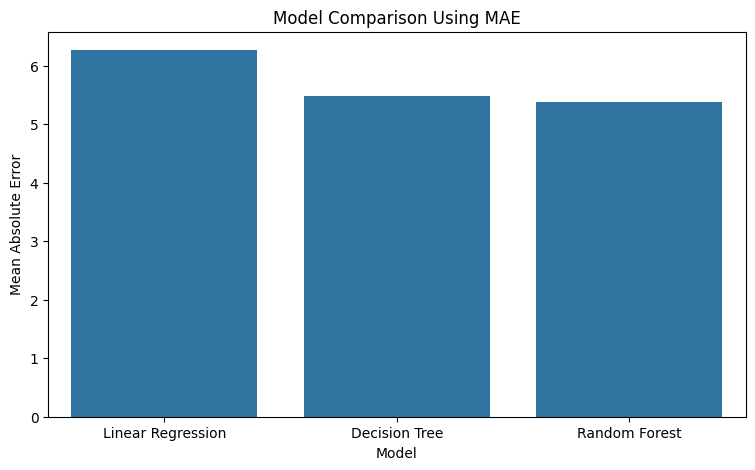

In [17]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=results,
    x="Model",
    y="MAE"
)

plt.title("Model Comparison Using MAE")
plt.ylabel("Mean Absolute Error")
plt.xlabel("Model")

plt.show()

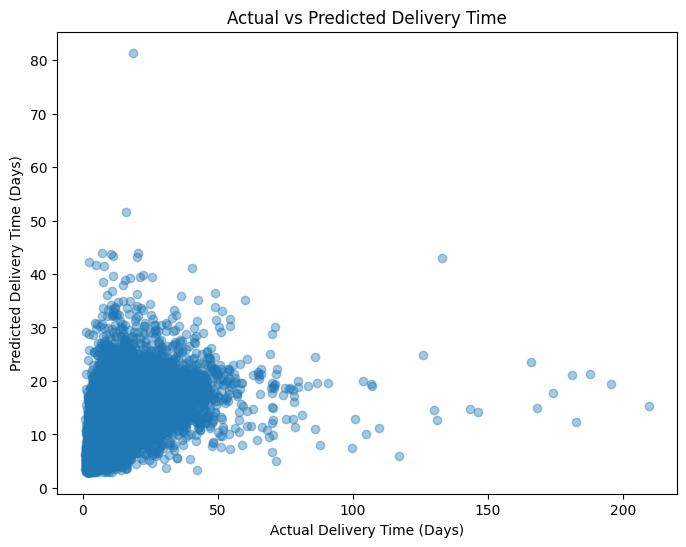

In [18]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    rf_pred,
    alpha=0.4
)

plt.xlabel("Actual Delivery Time (Days)")
plt.ylabel("Predicted Delivery Time (Days)")
plt.title("Actual vs Predicted Delivery Time")

plt.show()

In [19]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

print(importance)

            Feature  Importance
1     total_freight    0.386817
0       total_price    0.197260
5    purchase_month    0.131384
4      purchase_day    0.103759
3     purchase_hour    0.099143
6  purchase_weekday    0.052840
2   number_of_items    0.028797


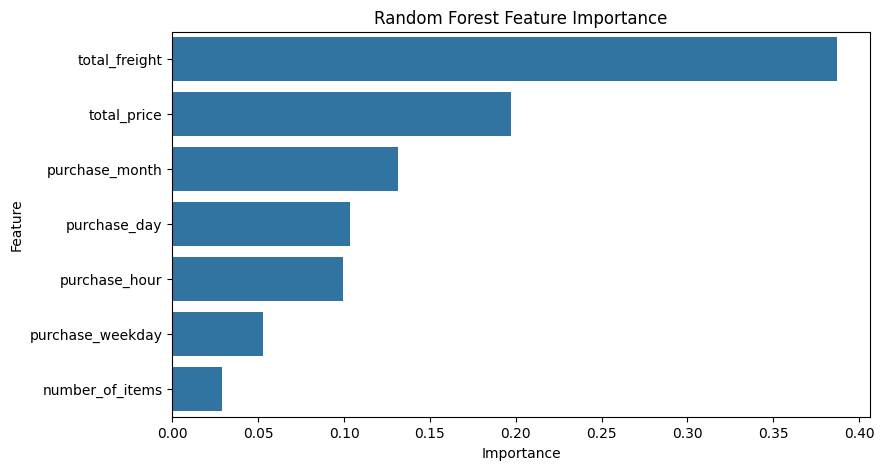

In [20]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [21]:
new_order = pd.DataFrame({
    "total_price": [500],
    "total_freight": [50],
    "number_of_items": [2],
    "purchase_hour": [14],
    "purchase_day": [10],
    "purchase_month": [8],
    "purchase_weekday": [2]
})

predicted_delivery = rf_model.predict(new_order)

print(
    f"Predicted Delivery Time: {predicted_delivery[0]:.2f} days"
)

Predicted Delivery Time: 9.92 days


In [22]:
test_results = X_test.copy()

test_results["actual_delivery_days"] = y_test.values
test_results["predicted_delivery_days"] = rf_pred

test_results["prediction_error"] = abs(
    test_results["actual_delivery_days"]
    - test_results["predicted_delivery_days"]
)

high_risk = test_results[
    test_results["predicted_delivery_days"] > 20
]

print("High-risk orders:", len(high_risk))

high_risk.head(10)

High-risk orders: 1466


,total_price,total_freight,number_of_items,purchase_hour,purchase_day,purchase_month,purchase_weekday,actual_delivery_days,predicted_delivery_days,prediction_error
56750,49.00,35.93,1.0,0,25,11,5,11.804155,33.581755,21.777600
92212,559.00,41.43,1.0,10,16,12,5,133.241146,42.918225,90.322921
66226,13.65,38.95,1.0,16,12,3,0,30.320683,22.068381,8.252302
88965,389.00,83.54,1.0,23,10,2,5,17.018438,21.905859,4.887422
87047,169.90,206.50,1.0,21,20,5,6,31.579780,23.357119,8.222661
29219,29.99,25.63,1.0,19,7,12,3,34.122153,22.120583,12.001569
33882,69.20,26.56,1.0,9,8,3,3,12.422384,21.418463,8.996079
83803,67.70,37.61,1.0,12,26,12,1,28.412674,21.875097,6.537577
21412,158.40,26.39,1.0,20,1,12,4,13.926470,21.612788,7.686318
948,99.00,17.94,1.0,3,26,11,6,15.813275,30.503530,14.690255


In [23]:
average_delivery = model_data["delivery_days"].mean()

print(f"Average Delivery Time: {average_delivery:.2f} days")

high_risk_percentage = (
    len(high_risk) / len(test_results)
) * 100

print(
    f"High-risk predicted orders: "
    f"{high_risk_percentage:.2f}%"
)

Average Delivery Time: 12.56 days
High-risk predicted orders: 7.60%
